<a href="https://colab.research.google.com/github/Juan-inf/ALURA/blob/main/Curso_Agentes_de_IA_y_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conexión con LLMs

In [ ]:
!pip install -q langchain langchain-google-genai google-generativeai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.6 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    google_api_key=GEMINI_API_KEY
)

In [ ]:
respuesta = llm.invoke("Qué es el RAG en Inteligencia Artificial?")

In [ ]:
respuesta.content

'El **RAG** (por sus siglas en inglés **Retrieval-Augmented Generation**, o Generación Aumentada por Recuperación) es una técnica en Inteligencia Artificial que mejora la capacidad de los Modelos de Lenguaje Grandes (LLMs, como GPT-4, Llama, etc.) para generar respuestas más precisas, relevantes y actualizadas.\n\nEn esencia, el RAG combina la capacidad de los LLMs para generar texto coherente con la capacidad de recuperar información específica de una base de datos o conjunto de documentos externos.\n\n### ¿Por qué es necesario el RAG?\n\nLos LLMs tienen algunas limitaciones inherentes:\n\n1.  **Conocimiento Limitado/Desactualizado:** Su conocimiento está limitado a los datos con los que fueron entrenados, que tienen una fecha de corte. No pueden acceder a información en tiempo real o a datos muy recientes.\n2.  **Alucinaciones:** A veces, los LLMs pueden "inventar" hechos o información que suena plausible pero es incorrecta, especialmente cuando no tienen suficiente información para 

In [ ]:
PROMPT_TRIAJE = """
	Eres un especialista en triaje del Service Desk para políticas internas.
	Dado el mensaje del usuario, devuelve SÓLO un JSON con:\n
	{\n
	 "decision": "AUTO_RESOLVER" | "PEDIR_INFO" | "ABRIR_TICKET",\n
	 "urgencia": "BAJA" | "MEDIANA" | "ALTA",\n
	 "campos_faltantes": ["..."]\n
	}\n
	Reglas:\n
	- **AUTO_RESOLVER**: Preguntas claras sobre las reglas o procedimientos descritos en las políticas (Ej.: "¿Puedo reembolsar el internet para mi oficina en casa?", "¿Cómo funciona la política de alimentación mientras viajo?").\n
	- **PEDIR_INFO**: Mensajes imprecisos o sin información para identificar el tema o el contexto (Ej.: "Necesito ayuda con una política", "Tengo una pregunta general").\n
	- **ABRIR_TICKET**: Solicitudes de excepciones, autorización, aprobación o acceso especial, o cuando el usuario solicita explícitamente abrir un ticket (Ej.: "Quiero una excepción para trabajar remotamente durante 5 días", "Solicito autorización para archivos adjuntos externos", "Por favor, abra un ticket con RR. HH.").\n
	Analiza el mensaje y decide la acción más adecuada.
"""

In [ ]:
from typing import Literal, List, Dict
from pydantic import BaseModel, Field

class TriajeOut(BaseModel):
  decision: Literal["AUTO_RESOLVER", "PEDIR_INFO", "ABRIR_TICKET"]
  urgencia: Literal["BAJA", "MEDIANA", "ALTA"]
  campos_faltantes: List[str] = Field(default_factory=list)

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage

chain_de_triaje = llm.with_structured_output(TriajeOut)

def triaje(mensaje: str) -> Dict:
  salida: TriajeOut = chain_de_triaje.invoke(
      [
          SystemMessage(content=PROMPT_TRIAJE),
          HumanMessage(content=mensaje)
      ]
  )
  return salida.model_dump()

In [ ]:
mensajes_de_prueba = [
	"¿Puedo obtener un reembolso por el internet de mi home office?",
	"Quiero una excepción para teletrabajar durante 5 días.",
	"¿Cómo funciona la política de comidas para viajes?",
	"¿Existe una política para anticipos de vacaciones?",
	"¿Quién fue Napoleón Bonaparte?"
]

for pregunta in mensajes_de_prueba:
  r = triaje(pregunta)
  print(f"{pregunta} -> {r}")

¿Puedo obtener un reembolso por el internet de mi home office? -> {'decision': 'AUTO_RESOLVER', 'urgencia': 'BAJA', 'campos_faltantes': []}
Quiero una excepción para teletrabajar durante 5 días. -> {'decision': 'ABRIR_TICKET', 'urgencia': 'MEDIANA', 'campos_faltantes': []}
¿Cómo funciona la política de comidas para viajes? -> {'decision': 'AUTO_RESOLVER', 'urgencia': 'BAJA', 'campos_faltantes': []}
¿Existe una política para anticipos de vacaciones? -> {'decision': 'AUTO_RESOLVER', 'urgencia': 'BAJA', 'campos_faltantes': []}
¿Quién fue Napoleón Bonaparte? -> {'decision': 'PEDIR_INFO', 'urgencia': 'BAJA', 'campos_faltantes': ['Contexto de política interna']}


# RAG

In [ ]:
!pip install -q langchain_community faiss-cpu langchain-text-splitters pymupdf

In [ ]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

docs = []

for documento in Path("/content/").glob("*.pdf"):
    try:
        loader = PyMuPDFLoader(str(documento))
        docs.extend(loader.load())
        print(f"Archivo cargado: {documento.name}")
    except Exception as e:
        print(f"Error cargando archivo: {documento.name}: {e}")

print(f"Total de documentos cargados: {len(docs)}")

Archivo cargado: Política de Reembolsos (Viajes y Gastos).pdf
Archivo cargado: Política de Teletrabajo (Home Office).pdf
Archivo cargado: Política de Uso de Correo Electrónico y Seguridad de la Información.pdf
Total de documentos cargados: 3


In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)
chunks = splitter.split_documents(docs)

In [ ]:
for chunk in chunks:
  print(chunk)
  print("------------------")

page_content='Política de Reembolsos (Viajes y 
Gastos) 
1. Objetivo Establecer las directrices y procedimientos para el reembolso de gastos 
incurridos por los empleados en el ejercicio de sus funciones oficiales, asegurando la 
transparencia, equidad y cumplimiento fiscal.' metadata={'producer': 'Skia/PDF m143 Google Docs Renderer', 'creator': '', 'creationdate': '', 'source': '/content/Política de Reembolsos (Viajes y Gastos).pdf', 'file_path': '/content/Política de Reembolsos (Viajes y Gastos).pdf', 'total_pages': 1, 'format': 'PDF 1.4', 'title': 'Política de Reembolsos (Viajes y Gastos)', 'author': '', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': '', 'page': 0}
------------------
page_content='2. Ámbito de Aplicación Esta política se aplica a todos los empleados fijos y temporales 
que incurran en gastos en nombre de la empresa. 
3. Gastos de Viaje 
●​ Transporte Aéreo: Se reembolsarán vuelos en clase económica. Cualquier mejora' meta

In [ ]:
len(chunks)

28

In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

modelo_embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=GEMINI_API_KEY
)

In [ ]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(chunks, modelo_embeddings)

retriever = vectorstore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"score_threshold": 0.3, "k": 4}
)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain.chains.combine_documents import create_stuff_documents_chain

prompt_rag = ChatPromptTemplate(
    [
        ("system",
         """
        Eres el especialista en RR.HH. de la empresa Carraro Desarrollo de Software.
        Responde siempre utilizando los conocimientos del contexto que te fue pasado.
        Si no hay información sobre la pregunta en el contexto, responde sólo 'No lo sé'.
        """),
        ("human", "Contexto: {context}.\nPregunta del empleado: {input}")
    ]
)

document_chain = create_stuff_documents_chain(llm, prompt_rag)

In [ ]:
def busqueda_de_respuestas_RAG(pregunta) -> Dict:
  documentos_relacionados = retriever.invoke(pregunta)

  if not documentos_relacionados:
    return {
        "respuesta": "No lo sé.",
        "citaciones": [],
        "documentos_encontrados": False
        }

  answer = document_chain.invoke({
      "input": pregunta,
      "context": documentos_relacionados
  })

  if answer.rstrip(".!?") == 'No lo sé':
    return {
        "respuesta": "No lo sé.",
        "citaciones": [],
        "documentos_encontrados": False
        }

  return {
        "respuesta": answer,
        "citaciones": documentos_relacionados,
        "documentos_encontrados": True
        }


In [ ]:
r = busqueda_de_respuestas_RAG("¿Puedo obtener un reembolso por el internet de mi home office?")
print(r)

{'respuesta': 'Sí, puedes obtener un reembolso por el internet de tu home office. Los empleados bajo el modelo de trabajo remoto (Home Office) aprobado pueden solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet, presentando la factura correspondiente.', 'citaciones': [Document(id='c4f2c766-5549-469b-aabc-0ae09fb9064e', metadata={'producer': 'Skia/PDF m143 Google Docs Renderer', 'creator': '', 'creationdate': '', 'source': '/content/Política de Reembolsos (Viajes y Gastos).pdf', 'file_path': '/content/Política de Reembolsos (Viajes y Gastos).pdf', 'total_pages': 1, 'format': 'PDF 1.4', 'title': 'Política de Reembolsos (Viajes y Gastos)', 'author': '', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': '', 'page': 0}, page_content='con recibo. \n●\u200b Internet (Home Office): Los empleados bajo el modelo de trabajo remoto (Home \nOffice) aprobado (ver Política de Home Office) pueden solicitar un reembolso \nmensual d

In [ ]:
len(r["citaciones"])

4

In [ ]:
mensajes_de_prueba = [
	"¿Puedo obtener un reembolso por el internet de mi home office?",
	"Quiero una excepción para teletrabajar durante 5 días.",
	"¿Cómo funciona la política de comidas para viajes?",
	"¿Existe una política para anticipos de vacaciones?",
	"¿Quién fue Napoleón Bonaparte?"
]

In [ ]:
for pregunta in mensajes_de_prueba:
  respuesta_RAG = busqueda_de_respuestas_RAG(pregunta)
  print(f"PREGUNTA: {pregunta}")
  print(f"RESPUESTA: {respuesta_RAG['respuesta']}")
  if respuesta_RAG['documentos_encontrados']:
    for i, citacion in enumerate(respuesta_RAG['citaciones']):
      print(f"    - CITACIÓN {i + 1}:")
      print(f"      Camino del documento: {citacion.metadata['file_path']}")
      print(f"      Contenido: {citacion.page_content.replace('\n', '')}")
  print("----------------------------------------------------------------")

PREGUNTA: ¿Puedo obtener un reembolso por el internet de mi home office?
RESPUESTA: Sí, puedes obtener un reembolso por el internet de tu home office. Los empleados bajo el modelo de trabajo remoto (Home Office) aprobado pueden solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet, presentando la factura correspondiente.
    - CITACIÓN 1:
      Camino del documento: /content/Política de Reembolsos (Viajes y Gastos).pdf
      Contenido: con recibo. ●​ Internet (Home Office): Los empleados bajo el modelo de trabajo remoto (Home Office) aprobado (ver Política de Home Office) pueden solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet, presentando la factura correspondiente.
    - CITACIÓN 2:
      Camino del documento: /content/Política de Teletrabajo (Home Office).pdf
      Contenido: en esta modalidad pueden solicitar el reembolso de gastos de internet hasta el límite establecido (35 EUR/mes). La empresa no reembolsará gastos de m

# Agente con LangGraph

In [ ]:
!pip install -q langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.6/207.6 kB 12.4 MB/s eta 0:00:00


In [ ]:
from typing import TypedDict, Optional

class AgentState(TypedDict, total = False):
  pregunta: str
  triaje: dict
  respuesta: Optional[str]
  citaciones: Optional[list]
  rag_exito: bool
  accion_final: str

In [ ]:
def nodo_triaje(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'triaje'...")
  return {"triaje": triaje(state["pregunta"])}

In [ ]:
def nodo_auto_resolver(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'auto_resolver'...")
  respuesta_RAG = busqueda_de_respuestas_RAG(state["pregunta"])

  update: AgentState = {
      "respuesta": respuesta_RAG["respuesta"],
      "citaciones": respuesta_RAG["citaciones"],
      "rag_exito": respuesta_RAG["documentos_encontrados"]
  }

  if respuesta_RAG["documentos_encontrados"]:
    update["accion_final"] = "AUTO_RESOLVER"

  return update

In [ ]:
def nodo_pedir_info(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'pedir_info'...")
  return {
      "respuesta": "Necesito más informaciones sobre tu pedido.",
      "citaciones": [],
      "accion_final": "PEDIR_INFO"
  }

In [ ]:
def nodo_abrir_ticket(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'abrir_ticket'...")

  tri = state["triaje"]

  return {
      "respuesta": f"Abrir ticket con urgencia {tri['urgencia']}. Pedido: {state['pregunta']}.",
      "citaciones": [],
      "accion_final": "ABRIR_TICKET"
  }

In [ ]:
def arista_decision_triaje(state: AgentState) -> str:
  print("Decidiendo el flujo después del nodo 'triaje'...")
  tri = state["triaje"]

  if tri["decision"] == "AUTO_RESOLVER":
    return "rag"
  elif tri["decision"] == "PEDIR_INFO":
    return "info"
  else:
    return "ticket"

In [ ]:
def arista_decision_rag(state: AgentState) -> str:
  print("Decidiendo el flujo después del nodo 'auto_resolver'...")

  if state["rag_exito"]:
    print("RAG con éxito, finalizando el flujo.")
    return "ok"

  KEYWORDS_ABRIR_TICKET = ["aprobación", "aprobar", "excepción", "liberación", "autorización",
                         "autorizar", "abrir ticket", "acceso especial"]

  if any(keyword in state["pregunta"].lower() for keyword in KEYWORDS_ABRIR_TICKET):
    print("RAG ha fallado, pero hay palabras relacionadas con abrir ticket.")
    return "ticket"

  print("RAG ha fallado, pediré más informaciones al usuario.")
  return "info"

In [ ]:
from langgraph.graph import START, END, StateGraph

workflow = StateGraph(AgentState)

workflow.add_node("triaje", nodo_triaje)
workflow.add_node("auto_resolver", nodo_auto_resolver)
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("abrir_ticket", nodo_abrir_ticket)

workflow.add_edge(START, "triaje")
workflow.add_conditional_edges("triaje", arista_decision_triaje, {
    "rag": "auto_resolver",
    "info": "pedir_info",
    "ticket": "abrir_ticket"
})

workflow.add_conditional_edges("auto_resolver", arista_decision_rag, {
    "info": "pedir_info",
    "ticket": "abrir_ticket",
    "ok": END
})

workflow.add_edge("pedir_info", END)
workflow.add_edge("abrir_ticket", END)

grafo = workflow.compile()

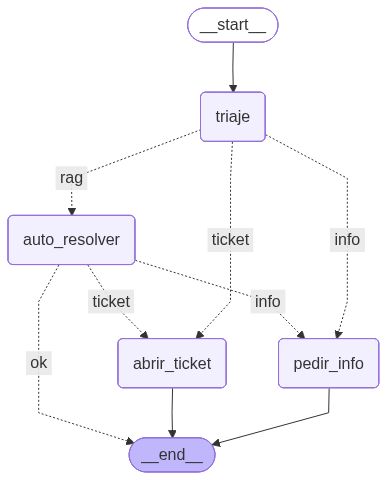

In [ ]:
from IPython.display import display, Image

graph_bytes = grafo.get_graph().draw_mermaid_png()
display(Image(graph_bytes))

In [ ]:
PREGUNTA = "Puedo reembolsar mi internet?"

respuesta = grafo.invoke({"pregunta": PREGUNTA})
print("")
print(f"PREGUNTA: {PREGUNTA}")
print(f"DECISIÓN DE TRIAJE: {respuesta['triaje']['decision']} | URGENCIA: {respuesta['triaje']['urgencia']} | ACCIÓN FINAL: {respuesta['accion_final']}")
print(f"RESPUESTA: {respuesta['respuesta']}")
if respuesta['citaciones']:
  for i, citacion in enumerate(respuesta['citaciones']):
    print(f"    - CITACIÓN {i + 1}:")
    print(f"      Camino del documento: {citacion.metadata['file_path']}")
    print(f"      Contenido: {citacion.page_content.replace('\n', '')}")

Ejecutando nodo 'triaje'...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...
Decidiendo el flujo después del nodo 'auto_resolver'...
RAG con éxito, finalizando el flujo.

PREGUNTA: Puedo reembolsar mi internet?
DECISIÓN DE TRIAJE: AUTO_RESOLVER | URGENCIA: BAJA | ACCIÓN FINAL: AUTO_RESOLVER
RESPUESTA: Sí, puedes solicitar el reembolso de tus gastos de conexión a internet. Los empleados bajo el modelo de trabajo remoto (Home Office) aprobado pueden solicitar un reembolso mensual de hasta 35 EUR, presentando la factura correspondiente.
    - CITACIÓN 1:
      Camino del documento: /content/Política de Reembolsos (Viajes y Gastos).pdf
      Contenido: con recibo. ●​ Internet (Home Office): Los empleados bajo el modelo de trabajo remoto (Home Office) aprobado (ver Política de Home Office) pueden solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet, presentando la factura correspondiente.
    - CITACIÓN 2:
      Camino del docu

In [ ]:
mensajes_de_prueba = [
	"¿Puedo obtener un reembolso por el internet de mi home office?",
	"Quiero una excepción para teletrabajar durante 5 días.",
	"¿Cómo funciona la política de comidas para viajes?",
	"¿Existe una política para anticipos de vacaciones?",
	"¿Quién fue Napoleón Bonaparte?"
]

In [ ]:
for prueba in mensajes_de_prueba:
  respuesta = grafo.invoke({"pregunta": prueba})
  print("")
  print(f"PREGUNTA: {prueba}")
  print(f"DECISIÓN DE TRIAJE: {respuesta['triaje']['decision']} | URGENCIA: {respuesta['triaje']['urgencia']} | ACCIÓN FINAL: {respuesta['accion_final']}")
  print(f"RESPUESTA: {respuesta['respuesta']}")
  if respuesta['citaciones']:
    for i, citacion in enumerate(respuesta['citaciones']):
      print(f"    - CITACIÓN {i + 1}:")
      print(f"      Camino del documento: {citacion.metadata['file_path']}")
      print(f"      Contenido: {citacion.page_content.replace('\n', '')}")
  print("-----------------------------------------------")

Ejecutando nodo 'triaje'...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...
Decidiendo el flujo después del nodo 'auto_resolver'...
RAG con éxito, finalizando el flujo.

PREGUNTA: ¿Puedo obtener un reembolso por el internet de mi home office?
DECISIÓN DE TRIAJE: AUTO_RESOLVER | URGENCIA: BAJA | ACCIÓN FINAL: AUTO_RESOLVER
RESPUESTA: Sí, puedes obtener un reembolso por el internet de tu home office. Los empleados bajo el modelo de trabajo remoto (Home Office) aprobado pueden solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet, presentando la factura correspondiente.
    - CITACIÓN 1:
      Camino del documento: /content/Política de Reembolsos (Viajes y Gastos).pdf
      Contenido: con recibo. ●​ Internet (Home Office): Los empleados bajo el modelo de trabajo remoto (Home Office) aprobado (ver Política de Home Office) pueden solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet, presentando la f